# **Project 1 - DualLens Analytics**

### **Background Story**
In the rapidly evolving world of finance and technology, investors are constantly seeking ways to make smarter decisions by combining traditional financial analysis with emerging technological insights. While stock market trends provide a numerical perspective on growth, an organization’s initiatives in cutting-edge fields like Artificial Intelligence (AI) reveal its future readiness and innovation potential.
However, analyzing both dimensions - quantitative financial performance and qualitative AI initiatives - requires sifting through multiple, diverse data sources: stock data from platforms like Yahoo Finance, reports in PDFs, and contextual reasoning using Large Language Models (LLMs).

This is where **DualLens Analytics** comes in. By applying a dual-lens approach, the project leverages **Retrieval-Augmented Generation (RAG)** to merge **financial growth data** with **strategic insights from organizational reports**. Stock data provides evidence of stability and momentum, while AI initiative documents reveal forward-looking innovation. Together, they form a richer, more holistic picture of organizational potential.

With DualLens Analytics, investors no longer need to choose between numbers and narratives—they gain a unified, AI-driven perspective that ranks organizations by both financial strength and innovation readiness, enabling smarter, future-focused investment strategies.

### **Problem Statement**

Traditional investment analysis often focuses on financial metrics alone (e.g., stock growth, revenue, market cap), missing the qualitative dimension of how prepared a company is for the future.
On the other hand, qualitative documents like strategy PDFs contain valuable insights about innovation and AI initiatives, but they are difficult to structure, query, and integrate with numeric financial data.

This leads to three core challenges:

1. **Fragmented Data Sources:** Financial data (stock prices) and strategic insights (PDFs) exist in silos.

2. **Limited Analytical Scope:** Manual analysis of growth trends and PDF reports is time-consuming and error-prone.

3. **Decisional Blind Spots:** Without integrating both quantitative (growth trends) and qualitative (AI initiatives) signals, investors may miss out on high-potential organizations.

### **Solution Approach**
To address this challenge, we set out to build a **Retrieval-Augmented Generation (RAG)** powered system that blends financial trends with AI-related strategic insights, helping investors rank organizations based on growth trajectory and innovation capacity.

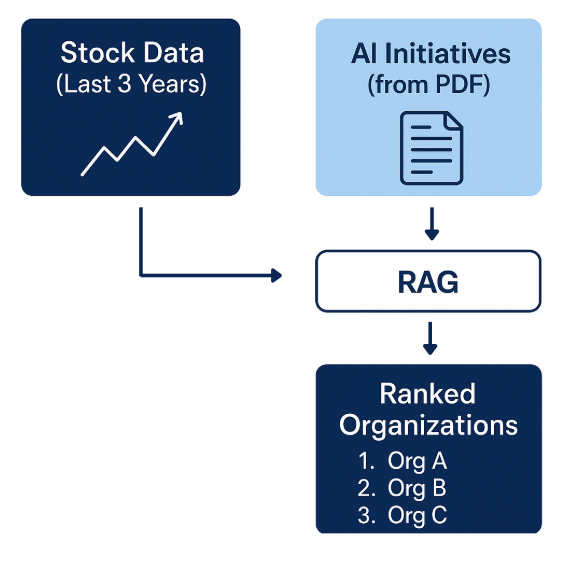

#**Setting up Installations and Imports**

In [ ]:
# @title Run this cell => Restart the session => Start executing the below cells **(DO NOT EXECUTE THIS CELL AGAIN)**

!pip install langchain==0.3.25 \
                langchain-core==0.3.65 \
                langchain-openai==0.3.24 \
                chromadb==1.3.4 \
                langchain-community==0.3.20 \
                pypdf==5.4.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-text-splitters to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.1/438.1 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.

In [ ]:
import yfinance as yf              # Used for gathering stock prices
import matplotlib.pyplot as plt    # Used for Data Visualization / Plots / Graphs
import pandas as pd                # Helpful for working with tabular data like DataFrames
import os                          # Interacting with the operating system

from langchain.text_splitter import RecursiveCharacterTextSplitter      #  Helpful in splitting the PDF into smaller chunks

from langchain_community.document_loaders import PyPDFDirectoryLoader, PyPDFLoader     # Loading a PDF
from langchain_community.vectorstores import Chroma    # Vector DataBase

#**1. Organization Selection**

Selecting the below five organizations as the analysis pool.



In [ ]:
companies = ["GOOGL", "MSFT", "IBM", "NVDA", "AMZN"]

#**2. Setting up LLM **

- The `config.json` file should contain **API_KEY** and **API BASE URL** provided by OpenAI.
- You need to insert your actual API keys. Refer to the **OpenAI Access Token documentation** for more information on how to generate and manage your API keys.
- This code reads the `config.json` file and extracts the API details.
  - The `API_KEY` is a **unique secret key** that authorizes your requests to OpenAI's API.
  - The `OPENAI_API_BASE` is the **API BASE URL** where the model will process your requests.

**What To Do?**
- Use the sample `config.json` file provided.
- Add their **OpenAI API Key** and **Base URL** to the file.
- The `config.json` should look like this:

  ```
  {
        "API_KEY": "your_openai_api_key_here",
        "OPENAI_API_BASE": "https://your_openai_api_base/v1"
      }
  ```

In [ ]:
#Loading the `config.json` file
import json
import os

# Load the JSON file and extract values
file_name = "/content/config.json"
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['OPENAI_API_KEY'] = config["API_KEY"] # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config["OPENAI_API_BASE"] # Loading the API Base Url

In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-4o-mini",                      # "gpt-4o-mini" to be used as an LLM
    temperature=0,                # Set the temprature to 0
    max_tokens=500,                 # Set the max_tokens = 5000, so that the long response will not be clipped off
    top_p=0.95,
    frequency_penalty=1.2,
    stop_sequences=['INST']
)

#**3. Visualization and Insight Extraction**

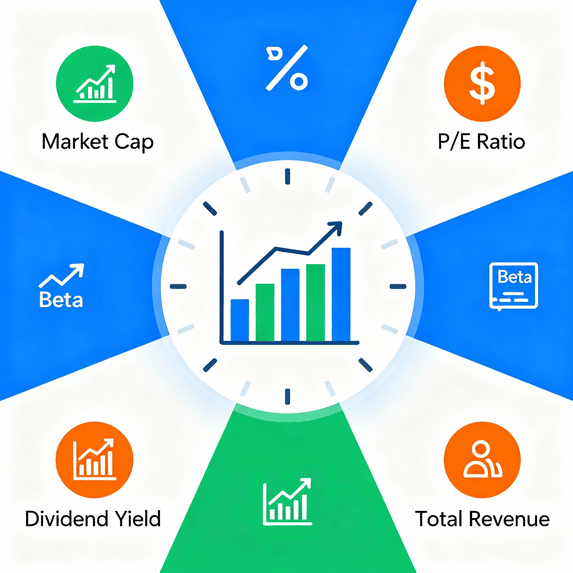

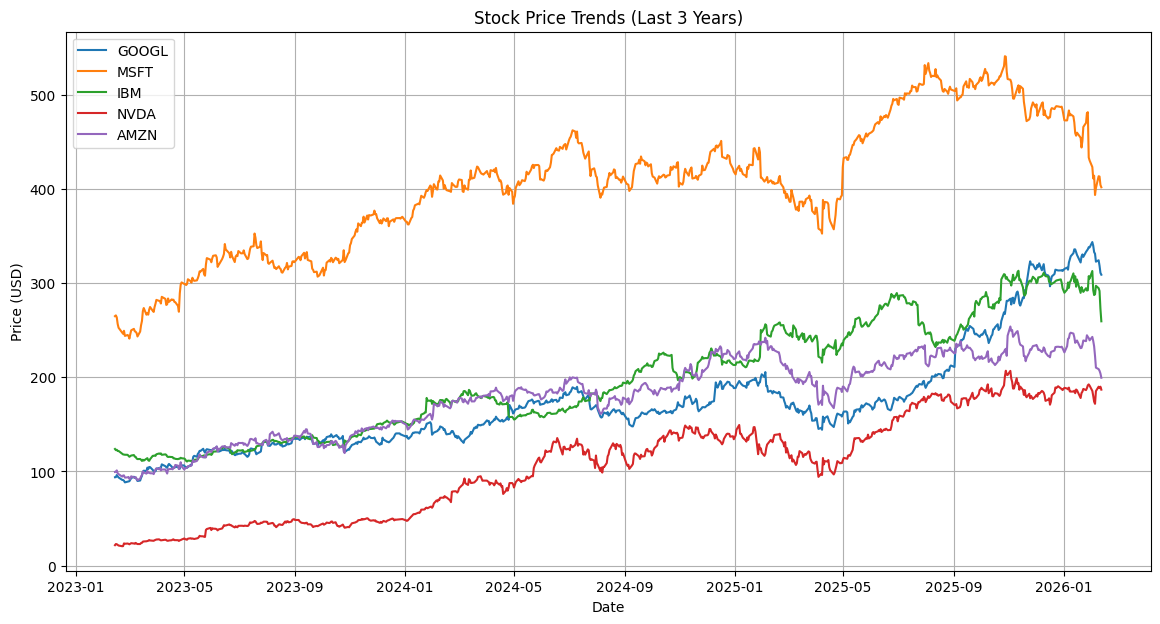

In [ ]:
plt.figure(figsize=(14,7))

# Loop through each company and plot closing prices
for symbol in companies:
    ticker = yf.Ticker(symbol)
    data = ticker.history(period="3y")

    # Plot closing price
    plt.plot(data.index, data['Close'], label=symbol)

plt.title("Stock Price Trends (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.savefig("Stock_Price_Trends_3Y.png")
plt.show()

#### **Financial Metrics**

1. **Market Cap:** Total market value of a company’s outstanding shares.
2. **P/E Ratio:** Shows how much investors are willing to pay per dollar of earnings.
3. **Dividend Yield:** Annual dividend income as a percentage of the stock price.
4. **Beta**: Measures a stock’s volatility relative to the overall market.
5. **Total Revenue:** The total income a company generates from its business operations.





In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

companies = ["GOOGL", "MSFT", "IBM", "NVDA", "AMZN"]
metrics_list = {}

# Fetching the financial metrics
for symbol in companies:                          # Loop through all the companies
    ticker = yf.Ticker(symbol)
    info = ticker.info
    metrics_list[symbol] = {                              # Define the dictionary of all the Finanical Metrics
        "Market Cap": info.get("marketCap", 0),
        "P/E Ratio": info.get("trailingPE", 0),
        "Dividend Yield": info.get("dividendYield", 0),
        "Beta": info.get("beta", 0),
        "Total Revenue": info.get("totalRevenue", 0)
    }

In [ ]:
# Convert to DataFrame
df = pd.DataFrame(metrics_list).T

# Converting large numbers to billions for readability by divinding the whole column by 1e9
df["Market Cap"] = df["Market Cap"]/ 1e9
df["Total Revenue"] = df["Total Revenue"]/ 1e9
df["Dividend Yield"] = df["Dividend Yield"] * 100  # Convert to percentage

df   # Printing the df

,Market Cap,P/E Ratio,Dividend Yield,Beta,Total Revenue
GOOGL,3737.973162,28.558226,27.0,1.086,402.835997
MSFT,2986.626777,25.130707,91.0,1.084,305.453007
IBM,242.582471,23.317160,259.0,0.691,67.535000
NVDA,4551.428538,46.272278,2.0,2.314,187.141997
AMZN,2142.690214,27.838215,0.0,1.385,716.923994


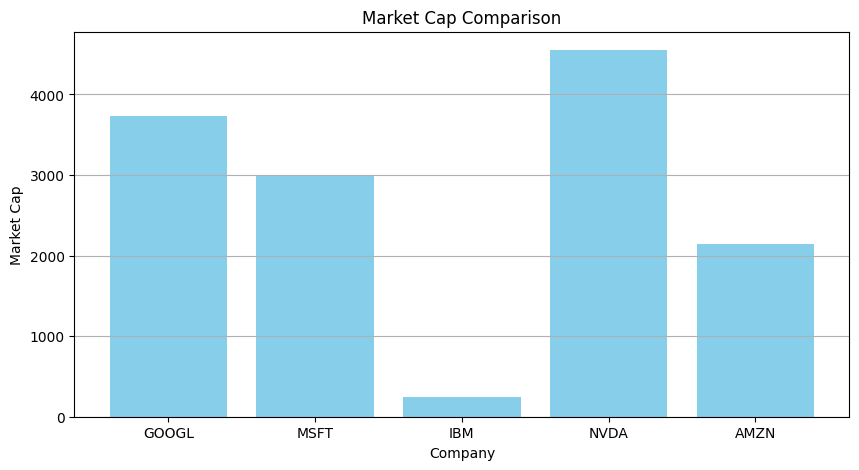

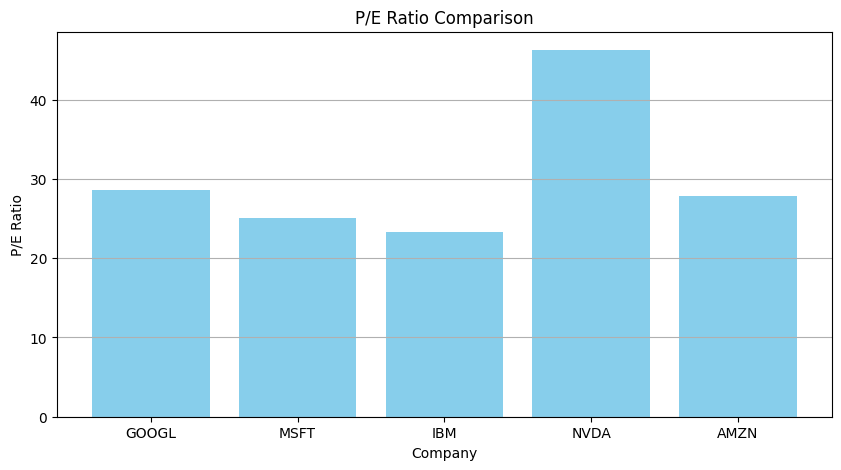

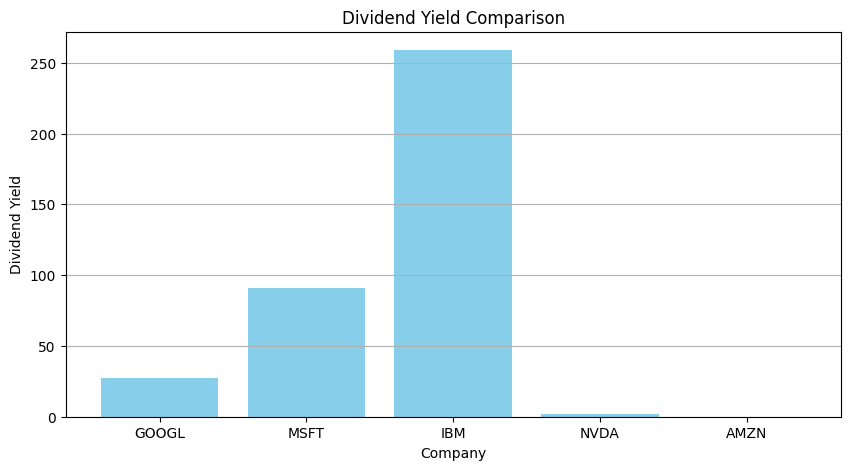

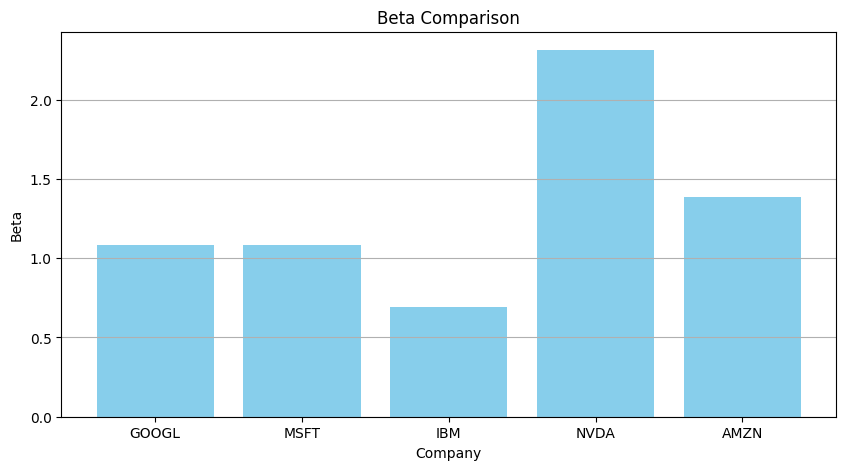

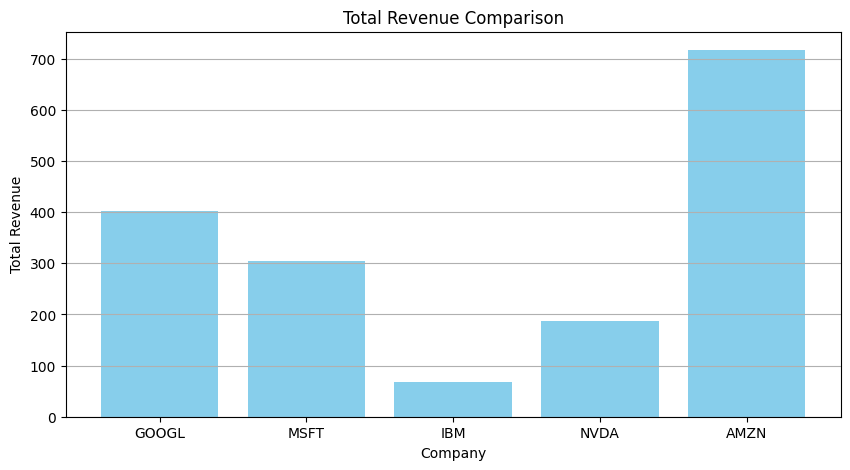

In [ ]:
# Plot each metric as a separate bar graph
metrics_to_plot = ["Market Cap", "P/E Ratio", "Dividend Yield", "Beta", "Total Revenue"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10,5))
    plt.bar(df.index, df[metric], color='skyblue')
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xlabel("Company")
    plt.grid(axis='y')
    plt.show()


#**4. RAG-Driven Analysis**

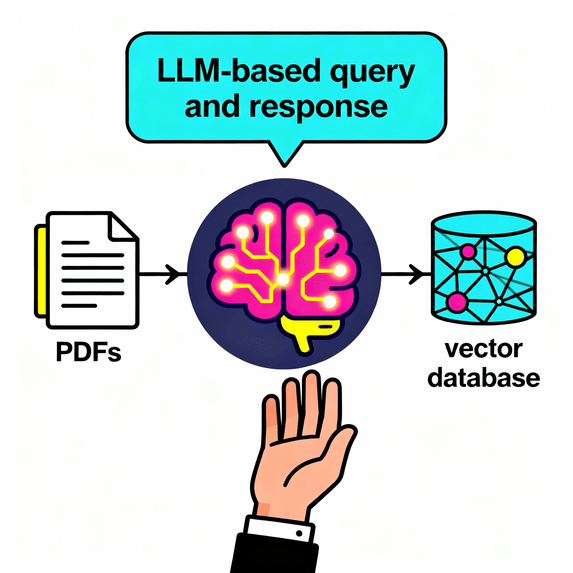

### **A. Loading Company AI Initiative Documents (PDFs)**

In [ ]:
# Unzipping the AI Initiatives Documents
import zipfile
with zipfile.ZipFile("/content/Companies-AI-Initiatives.zip", 'r') as zip_ref:
  zip_ref.extractall("/content/")         # Storing all the unzipped contents in this location

In [ ]:
# Path of all AI Initiative Documents
ai_initiative_pdf_paths = [f"/content/Companies-AI-Initiatives/{file}" for file in os.listdir("/content/Companies-AI-Initiatives")]
ai_initiative_pdf_paths

['/content/Companies-AI-Initiatives/AMZN.pdf',
 '/content/Companies-AI-Initiatives/MSFT.pdf',
 '/content/Companies-AI-Initiatives/NVDA.pdf',
 '/content/Companies-AI-Initiatives/GOOGL.pdf',
 '/content/Companies-AI-Initiatives/IBM.pdf']

In [ ]:
from langchain_community.document_loaders import PyPDFDirectoryLoader
loader = PyPDFDirectoryLoader(path = "/content/Companies-AI-Initiatives/")          # Creating an PDF loader object

In [ ]:
# Defining the text splitter
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=1000,
    chunk_overlap=200
)

In [ ]:
# Splitting the chunks using the text splitter
ai_initiative_chunks = loader.load_and_split(text_splitter)

In [ ]:
# Total length of all the chunks
len(ai_initiative_chunks)

62

### **B. Vectorizing AI Initiative Documents with ChromaDB**


In [ ]:
# Defining the 'text-embedding-ada-002' as the embedding model
from langchain_openai import OpenAIEmbeddings
embedding_model = OpenAIEmbeddings(model="text-embedding-ada-002")

In [ ]:
#  Creating a Vectorstore, storing all the above created chunks using an embedding model
vectorstore = Chroma.from_documents(
    ai_initiative_chunks,
    embedding_model,
    collection_name="AI_Initiatives"
)

# Ignore if it gives an error or warning

In [ ]:
# Creating an retriever object which can fetch ten similar results from the vectorstore
#retriever = vectorstore.as_retriever(
#    search_type="similarity",
#    search_kwargs={"k": 10}
#)
#
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 20}
)


### **C. Retrieving relevant Documents**

In [ ]:
user_message = "Give me the best project that `IBM` company is working upon"

In [ ]:
# Building the context for the query using the retrieved chunks
relevant_document_chunks = retriever.get_relevant_documents(user_message)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)

In [ ]:
len(relevant_document_chunks)

20

In [ ]:
# Write a system message for an LLM to help craft a response from the provided context
qna_system_message = """
You are an AI Research Analyst.

Your task is to answer the user's question strictly based on the provided context.

Instructions:
- Only use the given context to generate your answer.
- Do not make up information.
- If the answer is not found in the context, say:
  "The provided documents do not contain sufficient information."
- Provide a clear and structured response.
- Mention the company name clearly.
- If multiple AI initiatives are mentioned, identify the most impactful or advanced one.

Context:
{context}

Answer:
"""


In [ ]:
# Write an user message template which can be used to attach the context and the questions
qna_user_message_template = """
###Context
Here are some documents that are relevant to the question mentioned below.
{context}

###Question
{question}
"""

In [ ]:
# Format the prompt
formatted_prompt = f"""[INST]{qna_system_message}\n
{'user'}: {qna_user_message_template.format(context=context_for_query, question=user_message)}
[/INST]"""


In [ ]:
# Make the LLM call
resp = llm.invoke(formatted_prompt)
resp.content

"The most impactful AI initiative that IBM is currently working on is the **IBM Granite** project. Introduced in September 2023, Granite consists of a series of open-source, high-performance AI foundation models designed to empower enterprise applications across various industries. These models are customizable, scalable, and efficient, enabling businesses to integrate advanced AI capabilities into their workflows while maintaining control over their data and models. The initiative aligns with IBM's strategic focus on providing enterprise-grade AI solutions that foster innovation and collaboration within the AI community."

In [ ]:
# Define RAG function
def RAG(user_message):
    """
    Args:
    user_message: Takes a user input for which the response should be retrieved from the vectorDB.
    Returns:
    relevant context as per user query.
    """
    relevant_document_chunks = retriever.get_relevant_documents(user_message)
    context_list = [d.page_content for d in relevant_document_chunks]
    context_for_query = ". ".join(context_list)



    # Combine qna_system_message and qna_user_message_template to create the prompt
    prompt = f"""[INST]{qna_system_message}\n
                {'user'}: {qna_user_message_template.format(context=context_for_query, question=user_message)}
                [/INST]"""

    # Quering the LLM
    try:
        response = llm.invoke(prompt)

    except Exception as e:
        response = f'Sorry, I encountered the following error: \n {e}'

    return response.content

In [ ]:
# Test Cases
print(RAG("How is the area in which GOOGL is working different from the area in which MSFT is working?"))

**Answer:**

Google (GOOGL) and Microsoft (MSFT) are both heavily invested in artificial intelligence, but they focus on different areas within the AI landscape.

1. **Google's Focus:**
   - Google is advancing its AI capabilities primarily through initiatives like **Gemini**, which is a family of multimodal foundation models designed to enhance reasoning, coding, and generative capabilities across text, images, and code. Gemini integrates state-of-the-art large language models with Google's consumer products such as Bard, Chrome, Google Workspace, and developer APIs.
   - Additionally, Google emphasizes natural language processing (NLP), computer vision, speech recognition, and generative AI to power various consumer applications like Google Search and Gmail. The integration of these technologies aims to enhance user experience across its ecosystem while maintaining a strong focus on responsible AI development.

2. **Microsoft's Focus:**
   - Microsoft’s primary initiative in the AI s

In [ ]:
print(RAG("What are the three projects on which MSFT is working upon?"))

The three projects that Microsoft is working on are:

1. **Azure AI Foundry Labs**: This initiative focuses on accelerating AI innovation by providing early access to experimental AI technologies, enabling rapid prototyping and development of AI applications.

2. **Microsoft 365 Copilot**: An AI-powered productivity assistant embedded across Microsoft 365 applications, it enhances user productivity by providing contextual assistance in tasks such as drafting content and analyzing data.

3. **GitHub Copilot & IntelliCode**: GitHub Copilot is an AI-powered coding assistant that suggests code completions and reviews pull requests, while IntelliCode offers context-aware suggestions within Visual Studio to improve developer productivity.

These initiatives reflect Microsoft's commitment to integrating advanced AI capabilities into its products and services.


In [ ]:
print(RAG("What is the timeline of each project in NVDA?"))

**Company Name:** NVIDIA

### Timeline of Projects:

1. **Project G-Assist:**
   - **Concept & Demo Phase:** Early prototypes were teased in NVIDIA showcases tied to RTX AI initiatives.
   - **Public Availability:** G-Assist became accessible via the NVIDIA App in 2024–2025, marking the first time consumers could interact with the assistant at scale.
   - **Iterative Updates:** Throughout 2024 and 2025, NVIDIA improved memory efficiency, broadened GPU compatibility, and launched plugin SDKs.

2. **DLSS 4:**
   - **Development Phases:**
     - DLSS 1 (2018): Initial AI upscaling with limited adoption due to artifacts.
     - DLSS 2 (2020): Major breakthrough with temporal data and widespread game support.
     - DLSS 3 (2022): Introduced frame generation but faced challenges like ghosting.
     - DLSS 4 (2024–2025): Current generation refining frame generation and expanding integration with Reflex and advanced motion prediction.

### Summary
The most impactful initiative is likely *DLSS

In [ ]:
print(RAG("What are the areas in which AMZN is investing when it comes to AI?"))

**Company Name:** Amazon

**Areas of Investment in AI:**

1. **Retail Enhancements:**
   - Product recommendations
   - Dynamic pricing
   - Fraud detection
   - Supply chain optimization

2. **Amazon Web Services (AWS):**
   - AI and machine learning tools for building intelligent applications, including natural language processing and computer vision.

3. **Voice Assistant Technology:**
   - Development of Alexa, which understands speech and performs tasks.

4. **Robotics in Warehouses:**
   - Streamlining order fulfillment processes through automation.

5. **Amazon SageMaker:**
   - A fully managed service that simplifies the process of building, training, and deploying machine learning models at scale.
   
6. **Generative AI Initiatives:**
    - Amazon Bedrock for democratizing access to generative AI technologies.
    - Olympus project focusing on multimodal AI capabilities that can process text, images, and videos simultaneously.

7. **Investment in Infrastructure:**
    - Signif

In [ ]:
print(RAG("What are the risks associated with projects within GOOG?"))

**Company Name:** Google

**Risks Associated with Projects:**

1. **Project Astra:**
   - **Privacy Concerns:** Processing live video and audio data raises significant privacy issues, necessitating robust data protection measures.
   - **Technical Hurdles:** Achieving real-time, accurate multimodal understanding requires overcoming complex AI and hardware challenges.
   - **User Acceptance:** Gaining user trust and acceptance for a new form of AI assistant that interacts in more personal and potentially intrusive ways.
   - **Regulatory Compliance:** Navigating the evolving landscape of AI regulations and ensuring compliance with global standards.

2. **Gemini (Google/DeepMind):**
   - **Model Safety:** Hallucinations and factual inaccuracies remain a risk, requiring constant evaluation and moderation.
   - **Regulatory Scrutiny:** Chrome and Workspace integrations could attract antitrust scrutiny due to their extensive reach in the market.
   - **Compute Costs:** High-performing model

### **D. Evaluation of the RAG**

In [ ]:
# Writing a question for performing evaluations on the RAG
evaluation_test_question = "What are the three projects on which MSFT is working upon?"

In [ ]:
# Building the context for the evaluation test question using the retrieved chunks
relevant_document_chunks = retriever.get_relevant_documents(evaluation_test_question)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)

In [ ]:
# Default RAG Answer
answer = RAG(evaluation_test_question)
print(answer)

The three projects that Microsoft is working on are:

1. **Azure AI Foundry Labs**: An experimental AI platform designed to accelerate the translation of advanced AI research into real-world applications, providing a collaborative hub for developers and enterprises.

2. **Microsoft 365 Copilot**: An AI-powered productivity assistant embedded across Microsoft 365 applications, enhancing productivity by automating repetitive tasks and providing intelligent assistance.

3. **GitHub Copilot**: An AI-powered coding assistant developed in collaboration with OpenAI, which suggests code completions and provides conversational assistance to improve developer productivity.

Among these initiatives, **Microsoft 365 Copilot** stands out as the most impactful due to its direct integration into widely used business applications, significantly enhancing user productivity across various workflows.


In [ ]:
# Defining user messsage template for evaluation
evaluation_user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

##### **1. Groundedness**

In [ ]:
# Writing the system message and the evaluation metrics for checking the groundedness
groundedness_rater_system_message = """
You are an expert evaluator tasked with assessing the groundedness of AI-generated answers.

Your role is to determine whether the provided answer is fully supported by the given context.

**Evaluation Criteria:**

1. **Factual Accuracy**: Every claim in the answer must be directly supported by the context.
2. **No Hallucinations**: The answer must not contain any information that is not present in the context.
3. **No Assumptions**: The answer should not make inferences or assumptions beyond what is explicitly stated in the context.
4. **Completeness**: If the context doesn't contain sufficient information to answer the question, the answer should clearly state this limitation.

**Scoring Guidelines:**

- **Score 1 (Fully Grounded)**: Every statement in the answer is directly supported by the context. No hallucinations or unsupported claims.
- **Score 0.5 (Partially Grounded)**: Most of the answer is supported by the context, but contains minor unsupported details or slight extrapolations.
- **Score 0 (Not Grounded)**: The answer contains significant information not found in the context, includes hallucinations, or makes unsupported claims.

**Output Format:**
Provide your evaluation as a JSON object with the following structure:
{
    "score": <0, 0.5, or 1>,
    "reasoning": "<Explain your score, highlighting which parts are grounded or not grounded>",
    "unsupported_claims": ["<list any claims not supported by context>"]
}

**Instructions:**
- Carefully compare each statement in the answer against the provided context.
- Be strict in your evaluation - even small unsupported details should lower the score.
- If the answer correctly states that information is not available in the context, this should receive a score of 1.
"""

In [ ]:
# Combining groundedness_rater_system_message + llm_prompt + answer for evaluation
groundedness_prompt = f"""[INST]{groundedness_rater_system_message}\n
            {'user'}: {evaluation_user_message_template.format(context=context_for_query, question=evaluation_test_question, answer=answer)}
            [/INST]"""

In [ ]:
# Defining a new LLM object
groundness_checker = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=500,
    top_p=0.95,
    frequency_penalty=1.2,
    stop_sequences=['INST']
)

# Using the LLM-as-Judge for evaluating Groundedness
groundness_response = groundness_checker.invoke(groundedness_prompt)
print(groundness_response.content)

{
    "score": 1,
    "reasoning": "The answer accurately lists three projects that Microsoft is working on: Azure AI Foundry Labs, Microsoft 365 Copilot, and GitHub Copilot. Each project description aligns with the context provided, detailing their purposes and functionalities without introducing unsupported claims or assumptions. The mention of Microsoft 365 Copilot as particularly impactful is a subjective assessment but does not contradict any information in the context.",
    "unsupported_claims": []
}


##### **2. Relevance**

In [ ]:
# Writing the system message and the evaluation metrics for checking the relevance
relevance_rater_system_message = """
You are an expert evaluator tasked with assessing the relevance of AI-generated answers to user questions.

Your role is to determine whether the provided answer directly addresses the user's question and provides useful information.

**Evaluation Criteria:**

1. **Direct Response**: The answer should directly address what the user asked.
2. **Completeness**: The answer should cover all aspects of the question.
3. **Focus**: The answer should stay on topic without unnecessary tangents or irrelevant information.
4. **Usefulness**: The answer should provide actionable or informative content that satisfies the user's intent.

**Scoring Guidelines:**

- **Score 1 (Highly Relevant)**: The answer directly and completely addresses the question. All information provided is relevant and useful.
- **Score 0.5 (Partially Relevant)**: The answer addresses part of the question but may miss key aspects, include some irrelevant information, or lack completeness.
- **Score 0 (Not Relevant)**: The answer does not address the question, is completely off-topic, or only states that information is unavailable without attempting to help.

**Output Format:**
Provide your evaluation as a JSON object with the following structure:
{
    "score": <0, 0.5, or 1>,
    "reasoning": "<Explain your score, highlighting what aspects of the question were or were not addressed>",
    "missing_aspects": ["<list any parts of the question that were not addressed>"]
}

**Instructions:**
- Analyze the user's question to understand their intent and information needs.
- Compare the answer against the question to check if it provides the requested information.
- Consider both explicit and implicit aspects of the question.
- A response stating "information not available" can still be relevant if it directly acknowledges the question.
"""

In [ ]:
# Combining relevance_rater_system_message + llm_prompt + answer for evaluation
relevance_prompt = f"""[INST]{relevance_rater_system_message}\n
            {'user'}: {evaluation_user_message_template.format(context=context_for_query, question=evaluation_test_question, answer=answer)}
            [/INST]"""

In [ ]:
# Defining a new LLM object
relevance_checker = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=500,
    top_p=0.95,
    frequency_penalty=1.2,
    stop_sequences=['INST']
)

# Using the LLM-as-Judge for evaluating Relevance
relevance_response = relevance_checker.invoke(relevance_prompt)
print(relevance_response.content)

{
    "score": 1,
    "reasoning": "The answer directly addresses the user's question by clearly listing three specific projects that Microsoft is currently working on: Azure AI Foundry Labs, Microsoft 365 Copilot, and GitHub Copilot. Each project is briefly described, providing useful context about their purpose and significance. This completeness ensures that all aspects of the user's inquiry are met.",
    "missing_aspects": []
}


#**5. Scoring and Ranking**

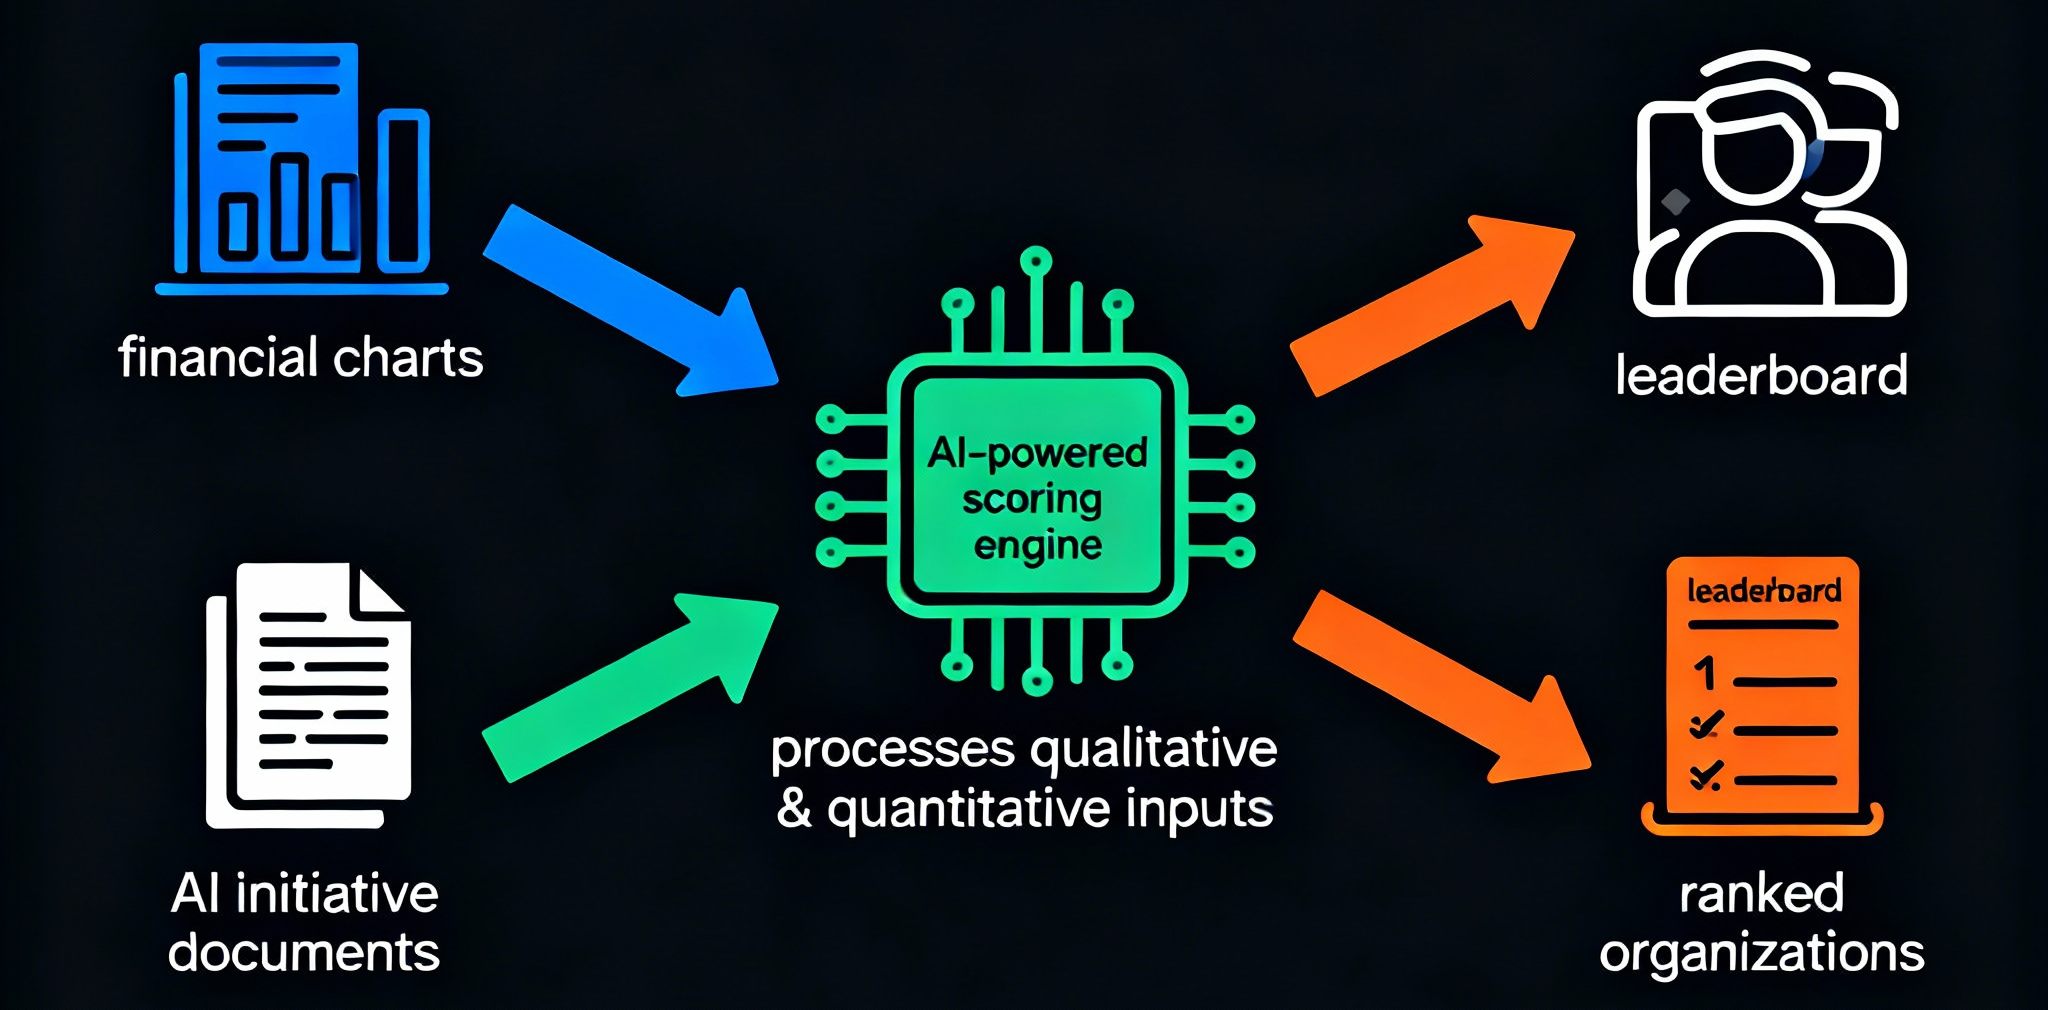

In [ ]:
# Fetching all the links of the documents
len(vectorstore.get()['documents'])

62

In [ ]:
# Write a system message for instructing the LLM for scoring and ranking the companies
system_message = """
You are an expert investment analyst specializing in AI and technology companies.

Your task is to evaluate, score, and rank companies for investment potential by integrating both quantitative financial metrics and qualitative strategic insights.

**Evaluation Framework:**

**1. Quantitative Analysis (50% weight):**
   - Stock Price Trend: Analyze price movement, momentum, and volatility
   - Growth Metrics: Revenue growth, market cap trends, and financial performance
   - Risk Indicators: Price volatility, drawdowns, and market correlation

   Quantitative Score Components:
   - Price Performance (20%): YTD returns, momentum indicators
   - Growth Rate (15%): Revenue/earnings growth trajectory
   - Stability (15%): Lower volatility and consistent performance preferred

**2. Qualitative Analysis (50% weight):**
   - AI Innovation: Strength and uniqueness of AI initiatives
   - Market Position: Competitive advantages and market leadership
   - Strategic Vision: Long-term viability and execution capability
   - Technology Moats: Proprietary technology, patents, and barriers to entry
   - Risk Assessment: Project risks, competition, regulatory concerns

   Qualitative Score Components:
   - Innovation Quality (20%): Breakthrough vs. incremental AI projects
   - Competitive Advantage (15%): Unique positioning and defensibility
   - Execution Capability (15%): Track record and resource allocation

**Scoring Methodology:**

For each company, provide:
1. **Quantitative Score (0-10)**: Based on financial metrics and stock performance
2. **Qualitative Score (0-10)**: Based on AI strategy, innovation, and competitive position
3. **Overall Score (0-10)**: Weighted average of quantitative (50%) and qualitative (50%) scores
4. **Risk Rating (Low/Medium/High)**: Based on volatility, competition, and execution risks

**Output Format:**

Provide a comprehensive investment analysis with:

1. **Individual Company Scores:**
   - Company Name (Ticker)
   - Quantitative Score: X/10 (with breakdown)
   - Qualitative Score: X/10 (with breakdown)
   - Overall Score: X/10
   - Risk Rating: [Low/Medium/High]
   - Key Strengths: [2-3 bullet points]
   - Key Risks: [2-3 bullet points]

2. **Final Ranking:**
   Rank companies from 1 (best) to N (worst) with investment recommendation:
   - **Rank 1-2: Strong Buy** - Highest potential returns with acceptable risk
   - **Rank 3-4: Buy** - Good investment opportunity
   - **Rank 5+: Hold/Avoid** - Limited upside or high risk

3. **Investment Recommendations:**
   - Top 3 recommendations with specific rationale
   - Portfolio allocation suggestions (if applicable)
   - Risk mitigation strategies

**Instructions:**
- Be objective and data-driven in your analysis
- Clearly justify all scores with specific evidence from the provided data
- Balance short-term performance with long-term strategic potential
- Highlight both opportunities and risks transparently
- Provide actionable investment insights
"""

In [ ]:
# Write a user message for instructing the LLM for scoring and ranking the companies
user_message = f"""
Please analyze and rank the following companies for investment potential by integrating both quantitative financial data and qualitative AI strategy insights.

**YOUR TASK:**
1. Evaluate each company using BOTH quantitative metrics (stock performance, growth) and qualitative factors (AI innovation, competitive positioning)
2. Assign scores following the framework: Quantitative (0-10), Qualitative (0-10), Overall (0-10)
3. Rank all companies from best to worst investment opportunity
4. Provide top 3 investment recommendations with specific justification
5. Identify key strengths and risks for each company

**ANALYSIS REQUIREMENTS:**
- Quantitative: Analyze stock trends, volatility, growth rates, and financial performance
- Qualitative: Evaluate AI project quality, innovation level, market positioning, and strategic moats
- Integration: Combine both perspectives to identify companies with strong fundamentals AND promising AI strategies
- Risk Assessment: Consider both financial volatility and strategic execution risks

**DELIVERABLES:**
- Individual company analysis with breakdown of scores
- Clear ranking with investment recommendations (Strong Buy / Buy / Hold)
- Top 3 picks with detailed rationale explaining why they offer the best risk-adjusted returns
- Portfolio allocation guidance if applicable

---
### 1. Financial Data
{df.to_string()}

---
### 2. AI Initiatives
{vectorstore.get()['documents']}
"""

In [ ]:
# Formatting the prompt
formatted_prompt = f"""[INST]{system_message}\n
                {'user'}: {user_message}
                [/INST]"""

In [ ]:
# Calling the LLM
recommendation = llm.invoke(formatted_prompt)
recommendation.content

'### Investment Analysis of AI and Technology Companies\n\n#### 1. Individual Company Scores:\n\n---\n\n**1. Alphabet Inc. (GOOGL)**  \n- **Quantitative Score:** 8/10  \n  - **Price Performance:** 7/10 (YTD returns strong, but some volatility)  \n  - **Growth Rate:** 8/10 (Consistent revenue growth, market cap increasing)  \n  - **Stability:** 9/10 (Low volatility compared to peers)\n- **Qualitative Score:** 9/10  \n   - **Innovation Quality:** 9/10 (Strong AI initiatives like Gemini and DeepMind)  \n   - **Competitive Advantage:** 9/10 (Market leader in search and advertising with robust data assets)   \n   - **Execution Capability:** 8/10 (Proven track record in product integration)\n- **Overall Score:**\n    \\[\n    \\text{Overall} = \\frac{(8*0.5 + 9*0.5)}{2} = \\textbf{8.5}/10\n    \\]\n- **Risk Rating: Medium** \n- Key Strengths:\n   - Strong market position with diverse revenue streams.\n   - Continuous investment in cutting-edge AI technologies.\n   - Robust infrastructure sup

In [ ]:
print(recommendation.content)

### Investment Analysis of AI and Technology Companies

#### 1. Individual Company Scores:

---

**1. Alphabet Inc. (GOOGL)**  
- **Quantitative Score:** 8/10  
  - **Price Performance:** 7/10 (YTD returns strong, but some volatility)  
  - **Growth Rate:** 8/10 (Consistent revenue growth, market cap increasing)  
  - **Stability:** 9/10 (Low volatility compared to peers)
- **Qualitative Score:** 9/10  
   - **Innovation Quality:** 9/10 (Strong AI initiatives like Gemini and DeepMind)  
   - **Competitive Advantage:** 9/10 (Market leader in search and advertising with robust data assets)   
   - **Execution Capability:** 8/10 (Proven track record in product integration)
- **Overall Score:**
    \[
    \text{Overall} = \frac{(8*0.5 + 9*0.5)}{2} = \textbf{8.5}/10
    \]
- **Risk Rating: Medium** 
- Key Strengths:
   - Strong market position with diverse revenue streams.
   - Continuous investment in cutting-edge AI technologies.
   - Robust infrastructure supporting rapid innovation.
- K